# **실습 : 이진분류**

* 회사 인사팀에서는 여러분들에게 직원의 이직여부과 관련해서 분석을 요청하였다.
* 어떤 직원이 이직할지 예측해 봅시다.


## **1.환경준비**

### (1) 라이브러리 Import

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [22]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

### (2) 필요 함수 생성

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [23]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [24]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [25]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [26]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [27]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### (4) 데이터로딩

In [28]:
path = "Attrition_train_validation.csv"
df = pd.read_csv(path)
df['Attrition'] = np.where(df['Attrition']=='Yes', 1, 0)
df.head(10)

,Attrition,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,OverTime,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
0,0,33,Travel_Rarely,Research & Development,7,3,Medical,817,3,Male,...,No,11,4,0,14,3,4,13,9,7
1,0,35,Travel_Frequently,Research & Development,18,2,Life Sciences,1412,3,Male,...,No,11,3,0,10,2,3,2,2,2
2,0,42,Travel_Rarely,Research & Development,6,3,Medical,1911,3,Male,...,No,13,2,1,18,3,4,13,7,7
3,0,46,Travel_Rarely,Sales,2,3,Marketing,1204,3,Female,...,No,23,1,0,28,2,3,26,15,9
4,0,39,Travel_Frequently,Sales,20,3,Life Sciences,1812,3,Male,...,No,18,4,1,7,6,3,2,1,2
5,1,22,Travel_Frequently,Research & Development,4,1,Technical Degree,593,3,Male,...,No,16,3,0,4,3,3,2,2,2
6,0,24,Travel_Rarely,Research & Development,21,2,Technical Degree,1551,3,Male,...,No,14,2,3,2,3,3,1,1,0
7,0,34,Travel_Rarely,Research & Development,8,3,Medical,2068,2,Male,...,No,12,1,0,6,3,4,4,3,2
8,0,30,Travel_Rarely,Research & Development,20,3,Other,1084,3,Male,...,No,15,3,1,7,1,2,6,2,2
9,0,26,Travel_Rarely,Research & Development,6,3,Life Sciences,686,3,Female,...,Yes,13,3,1,3,2,3,3,2,2


|	변수 명	|	내용	|	구분	|
|	----	|	----	|	----	|
|	**Attrition**	|	이직여부, Yes = 1 , No = 0	|	**Target**	|
|	Age	|	나이	|	숫자	|
|	BusinessTravel	|	출장 빈도(범주)	|		|
|	Department	|	현 부서	|		|
|	DistanceFromHome	|	집-직장 거리(마일)	|	숫자	|
|	Education	|	교육수준(범주)	|	1 Below College, 2 College, 3 Bachelor, 4 Master, 5 Doctor	|
|	EducationField	|	전공	|		|
|	EmployeeNumber	|	사번	|		|
|	EnvironmentSatisfaction	|	근무환경에 대한 만족도(범주)	|	1 Low, 2 Good, 3 Excellent, 4 Outstanding	|
|	Gender	|	성별	|		|
|	JobInvolvement	|	직무 적극성(참여도)	|	1 Low, 2 Medium, 3 High, 4 Very High	|
|	JobRole	|	직무	|		|
|	JobSatisfaction	|	직무 만족도	|	1 Low, 2 Medium, 3 High, 4 Very High	|
|	MaritalStatus	|	결혼상태	| Single, Married, Divorced		|
|	MonthlyIncome	|	월급	|	숫자	|
|	NumCompaniesWorked	|	현재까지 근무한 회사 수	|	숫자	|
|	OverTime	|	야근여부	|	범주	|
|	PercentSalaryHike	|	전년대비 급여인상율(%)	|	숫자	|
|	RelationshipSatisfaction	|	동료와의 관계 만족도	|	1 Low, 2 Medium, 3 High, 4 Very High	|
|	StockOptionLevel	|	스톡옵션 수준 0~3	|	범주	|
|	TotalWorkingYears	|	총 근무 연수	|	숫자	|
|	TrainingTimesLastYear	|	전년 교육훈련 횟수	|	숫자	|
|	WorkLifeBalance	|	워라밸. 일-삶 균형도	|	1 Bad, 2 Good, 3 Better, 4 Best	|
|	YearsAtCompany	|	현직장 근무 연수	|	숫자	|
|	YearsInCurrentRole	|	현직무 연수	|	숫자	|
|	YearsWithCurrManager	|	현 팀장과 근무한 연수	|	숫자	|


## **2.데이터 준비**

### (1) 데이터 준비
* x, y 나누기
    * x : lstat, ptratio, crim
    * y : medv

In [29]:
target = 'Attrition'
X = df.drop(target, axis = 1)
y = df.loc[:, target]

### (2) 가변수화

In [30]:
object_columns = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=object_columns, drop_first=True)


### (3) 데이터분할

In [31]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.2, random_state = 20)

### (4) Scaling

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

### (5) 텐서로 변환, 데이터로더 준비

In [33]:
train_loader, X_val_ts, y_val_ts = make_DataSet(X_train, X_val, y_train, y_val, 32)

In [34]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f"Shape of x [rows, columns]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [rows, columns]: torch.Size([32, 39])
Shape of y: torch.Size([32, 1]) torch.float32


## **3.모델링1**

### (1) 모델 선언

In [35]:
n_feature = X.shape[1]
n_feature

39

In [56]:
# 모델 구조 설계
model = nn.Sequential(
            nn.Linear(n_feature, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        ).to(device)

print(model)

Sequential(
  (0): Linear(in_features=39, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
  (7): Sigmoid()
)


In [57]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.0001)

### (2) 학습

In [ ]:
epochs = 300
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

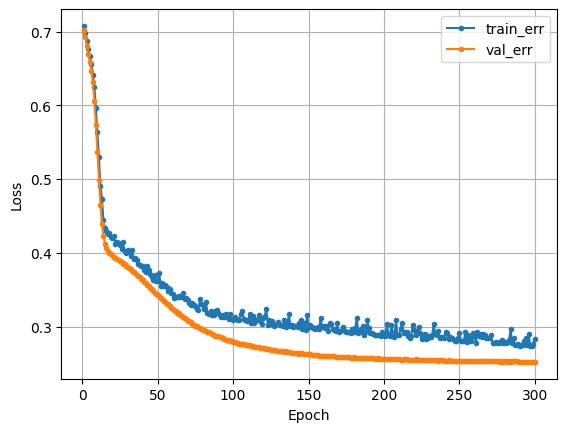

In [59]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

In [40]:
_, pred = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)
pred = np.where(pred.numpy() > .5, 1, 0)

In [41]:
confusion_matrix(y_val_ts.numpy(), pred)

array([[204,  10],
       [ 18,  18]])

In [42]:
print(f'Accuracy : {accuracy_score(y_val_ts.numpy(), pred)}')
print('-'*60)
print(classification_report(y_val_ts.numpy(), pred))

Accuracy : 0.888
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94       214
         1.0       0.64      0.50      0.56        36

    accuracy                           0.89       250
   macro avg       0.78      0.73      0.75       250
weighted avg       0.88      0.89      0.88       250



## **4.모델링2**

### (1) 모델 선언

In [72]:
# 모델 구조 설계
model2 = nn.Sequential(
            nn.Linear(n_feature, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, 2),
            nn.ReLU(),
            nn.Linear(2, 1),
            nn.Sigmoid()
        ).to(device)

print(model2)

Sequential(
  (0): Linear(in_features=39, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=2, bias=True)
  (5): ReLU()
  (6): Linear(in_features=2, out_features=1, bias=True)
  (7): Sigmoid()
)


In [73]:
loss_fn = nn.BCELoss()
optimizer = Adam(model2.parameters(), lr=0.0001)

### (2) 학습

In [74]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss,_ = evaluate(X_val_ts, y_val_ts, model2, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.726421, val loss : 0.722201
Epoch 2, train loss : 0.715674, val loss : 0.709338
Epoch 3, train loss : 0.702681, val loss : 0.694580
Epoch 4, train loss : 0.688171, val loss : 0.677425
Epoch 5, train loss : 0.669809, val loss : 0.655310
Epoch 6, train loss : 0.648755, val loss : 0.629209
Epoch 7, train loss : 0.622860, val loss : 0.603625
Epoch 8, train loss : 0.598874, val loss : 0.576291
Epoch 9, train loss : 0.573398, val loss : 0.549075
Epoch 10, train loss : 0.548236, val loss : 0.522591
Epoch 11, train loss : 0.525264, val loss : 0.498331
Epoch 12, train loss : 0.501414, val loss : 0.476986
Epoch 13, train loss : 0.485536, val loss : 0.457726
Epoch 14, train loss : 0.467989, val loss : 0.443282
Epoch 15, train loss : 0.452990, val loss : 0.431173
Epoch 16, train loss : 0.442751, val loss : 0.421949
Epoch 17, train loss : 0.441637, val loss : 0.415795
Epoch 18, train loss : 0.435900, val loss : 0.410629
Epoch 19, train loss : 0.436562, val loss : 0.406913
Ep

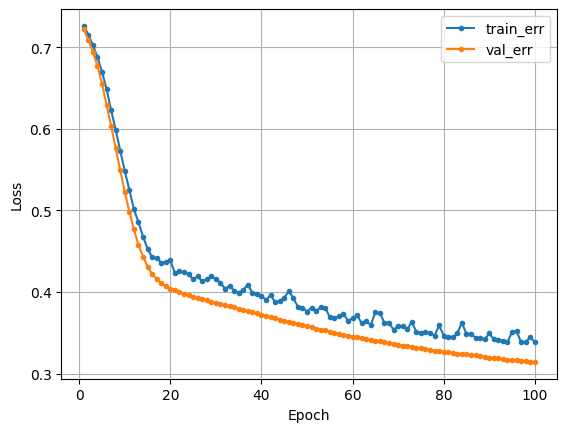

In [75]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

In [76]:
_, pred = evaluate(X_val_ts, y_val_ts, model2, loss_fn, device)
pred = np.where(pred.numpy() > .5, 1, 0)

In [77]:
confusion_matrix(y_val_ts.numpy(), pred)

array([[214,   0],
       [ 30,   6]])

In [78]:
print(f'Accuracy : {accuracy_score(y_val_ts.numpy(), pred)}')
print('-'*60)
print(classification_report(y_val_ts.numpy(), pred))

Accuracy : 0.88
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.93       214
         1.0       1.00      0.17      0.29        36

    accuracy                           0.88       250
   macro avg       0.94      0.58      0.61       250
weighted avg       0.89      0.88      0.84       250



## **5.모델링3**

### (1) 모델 선언

In [79]:
# 모델 구조 설계
model3 = nn.Sequential(
            nn.Linear(n_feature, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 2),
            nn.ReLU(),
            nn.Linear(2, 2),
            nn.ReLU(),
            nn.Linear(2, 1),
            nn.Sigmoid()
        ).to(device)

print(model3)

Sequential(
  (0): Linear(in_features=39, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=16, bias=True)
  (7): ReLU()
  (8): Linear(in_features=16, out_features=8, bias=True)
  (9): ReLU()
  (10): Linear(in_features=8, out_features=8, bias=True)
  (11): ReLU()
  (12): Linear(in_features=8, out_features=2, bias=True)
  (13): ReLU()
  (14): Linear(in_features=2, out_features=2, bias=True)
  (15): ReLU()
  (16): Linear(in_features=2, out_features=1, bias=True)
  (17): Sigmoid()
)


In [80]:
loss_fn = nn.BCELoss()
optimizer = Adam(model3.parameters(), lr=0.0001)

### (2) 학습

In [81]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss,_ = evaluate(X_val_ts, y_val_ts, model3, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.612001, val loss : 0.606434
Epoch 2, train loss : 0.610364, val loss : 0.605536
Epoch 3, train loss : 0.609513, val loss : 0.604639
Epoch 4, train loss : 0.609489, val loss : 0.603735
Epoch 5, train loss : 0.609477, val loss : 0.602871
Epoch 6, train loss : 0.608678, val loss : 0.601991
Epoch 7, train loss : 0.607027, val loss : 0.601134
Epoch 8, train loss : 0.606222, val loss : 0.600243
Epoch 9, train loss : 0.607123, val loss : 0.599371
Epoch 10, train loss : 0.604598, val loss : 0.598538
Epoch 11, train loss : 0.604678, val loss : 0.597665
Epoch 12, train loss : 0.603887, val loss : 0.596804
Epoch 13, train loss : 0.603099, val loss : 0.595953
Epoch 14, train loss : 0.601410, val loss : 0.595107
Epoch 15, train loss : 0.601526, val loss : 0.594257
Epoch 16, train loss : 0.601669, val loss : 0.593415
Epoch 17, train loss : 0.599984, val loss : 0.592570
Epoch 18, train loss : 0.597327, val loss : 0.591744
Epoch 19, train loss : 0.598428, val loss : 0.590895
Ep

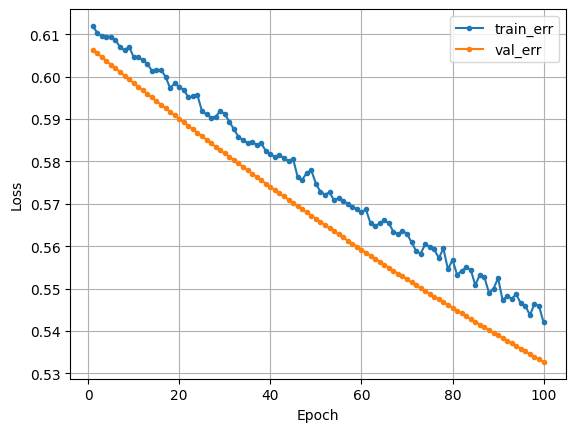

In [82]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

In [83]:
_, pred = evaluate(X_val_ts, y_val_ts, model3, loss_fn, device)
pred = np.where(pred.numpy() > .5, 1, 0)

In [84]:
confusion_matrix(y_val_ts.numpy(), pred)

array([[214,   0],
       [ 36,   0]])

In [85]:
print(f'Accuracy : {accuracy_score(y_val_ts.numpy(), pred)}')
print('-'*60)
print(classification_report(y_val_ts.numpy(), pred))

Accuracy : 0.856
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92       214
         1.0       0.00      0.00      0.00        36

    accuracy                           0.86       250
   macro avg       0.43      0.50      0.46       250
weighted avg       0.73      0.86      0.79       250



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
